# Setup

In [1]:
from pathlib import Path
import seaborn as sns
sns.set_theme()
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from scipy import stats
from adjustText import adjust_text
import sys
sys.path.insert(0, '../../poverty/dry_run/learn')
from formatting import METHODS
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [2]:
# Deal with floating point/rounding in file naming
def get_tranfers_file_for_budget(
    country_results_path, name_root, budget
):
    if (country_results_path / f'{name_root}_budget={budget}.csv').exists():
        filename = country_results_path / f'{name_root}_budget={budget}.csv'
    else:
        closest_budget_file = None
        closest_difference = float('inf')
        for file in country_results_path.glob(f'{name_root}_budget=*.csv'):
            file_budget = float(file.stem.split('=')[-1])
            difference = abs(file_budget - budget)
            if difference < closest_difference:
                closest_difference = difference
                closest_budget_file = file
        print(f'Warning: budget={budget} not found, using budget={closest_budget_file.stem.split("=")[-1]} instead.')
        filename = closest_budget_file
    return filename, pd.read_csv(filename)

def weighted_spearman(x, y, weights):
    x = np.asarray(x)
    y = np.asarray(y)
    weights = np.asarray(weights)
    weights = weights / weights.sum()
    x_ranks = stats.rankdata(x)
    y_ranks = stats.rankdata(y)
    x_mean = np.average(x_ranks, weights=weights)
    y_mean = np.average(y_ranks, weights=weights)
    cov = np.sum(weights * (x_ranks - x_mean) * (y_ranks - y_mean))
    x_std = np.sqrt(np.sum(weights * (x_ranks - x_mean)**2))
    y_std = np.sqrt(np.sum(weights * (y_ranks - y_mean)**2))
    return cov / (x_std * y_std)

def concentration_index(welfare, transfers, weights):
    """
    Compute the weighted concentration index of transfers.

    Households are ranked by welfare (ascending). The index equals
    2 * cov_w(transfers, fractional_rank) / mean_w(transfers), which
    lies in [-1, 1]. Negative values indicate pro-poor concentration
    (transfers skewed toward lower-welfare households).
    """
    welfare = np.asarray(welfare)
    transfers = np.asarray(transfers)
    weights = np.asarray(weights, dtype=float)

    sort_idx = np.argsort(welfare)
    transfers = transfers[sort_idx]
    weights = weights[sort_idx]

    weights = weights / weights.sum()
    # Fractional rank: midpoint of cumulative weight for each observation
    cumw = np.cumsum(weights)
    rank = cumw - weights / 2  # midpoint rank in [0, 1]

    mean_t = np.sum(weights * transfers)
    ci = 2 * np.sum(weights * transfers * rank) / mean_t - 1
    return ci


In [3]:
data = []

rate_target = 0.01

top_level_results_path = Path(
    f'/data/eop/simulation_results/results_eoy_2025/'
)

for subdir in top_level_results_path.iterdir():
    country = subdir.name
    togo_country_results_path = subdir / 'geo_extrapolation' / 'year=2017'

    per_capita_costs = dict()
    nearest_budgets = dict()

    for method in ['output_gt_continuous_gap', 'oracle_gap', 'ubi']:
        overall_results = pd.read_csv(togo_country_results_path / f'{method}.csv')

        post_transfer_poverty_rate = overall_results['post_transfer_poverty_rate'].values
        budget = overall_results['budget'].values
        optimal_budget = np.interp(rate_target, post_transfer_poverty_rate[::-1], budget[::-1])

        eligible_budgets = overall_results[overall_results['post_transfer_poverty_rate'] <= rate_target]['budget'].values
        assert len(eligible_budgets) > 0
        nearest_budget_idx = np.argmin(np.abs(eligible_budgets - optimal_budget))
        nearest_budget = eligible_budgets[nearest_budget_idx]

        per_capita_costs[method] = optimal_budget
        nearest_budgets[method] = nearest_budget


    realistic_over_oracle = per_capita_costs['output_gt_continuous_gap'] / per_capita_costs['oracle_gap']
    ubi_over_targeting = per_capita_costs['ubi'] / per_capita_costs['output_gt_continuous_gap']


    tranfers_filename, transfers = get_tranfers_file_for_budget(
        togo_country_results_path, 'output_gt_continuous_gap', nearest_budgets['output_gt_continuous_gap']
    )
    test_set = pd.read_parquet(
        f'/data/eop/20251209_snapshot_country_data/{country}/test.parquet'
    ).reset_index(drop=True)
    if not len(test_set) == len(transfers):
        print(f'length mismatch: country {country}, test set {len(test_set)}, transfers {len(transfers)}')
        continue
    joined = test_set.join(transfers)
    
    spearman = weighted_spearman(joined.consumption, -joined.ev_transfer, joined.headcount_adjusted_hh_wgt)
    ci = concentration_index(joined.consumption, joined.ev_transfer, joined.headcount_adjusted_hh_wgt)

    data.append({
        'country': country,
        # Should match across all results sets, so doesn't matter which "overall_results" this ends up being.
        'initial_poverty_rate': overall_results.initial_poverty_rate.values[0],
        'realistic_over_oracle': realistic_over_oracle,
        'ubi_over_targeting': ubi_over_targeting,
        'targeting_over_ubi': 1/ubi_over_targeting,
        'spearman': spearman,
        'transfers_filename': tranfers_filename,
        'concentration_index': ci,
    })
data = pd.DataFrame(data)

In [4]:
# Togo: load transfers for each method at the same rate target
country = "TGO"
rate_target = 0.01
togo_country_results_path = top_level_results_path / country / "geo_extrapolation" / "year=2017"

tgo_dfs = []
test_set = pd.read_parquet(
    f'/data/eop/country_data/TGO/cleaned/test.parquet'
).reset_index(drop=True)

survey_locations = pd.read_csv(
    '/data/togo_anon/surveys/survey2018outcomes.csv',
    usecols=['hhid', 'latitude', 'longitude', 'region', 'prefecture', 'canton', 'cluster']
)
for method in ["output_gt_continuous_gap", "oracle_gap", "ubi", "output_gt_pmt"]:
    overall_results = pd.read_csv(togo_country_results_path / f"{method}.csv")
    post_transfer_poverty_rate = overall_results["post_transfer_poverty_rate"].values
    budget = overall_results["budget"].values
    optimal_budget = np.interp(rate_target, post_transfer_poverty_rate[::-1], budget[::-1])
    eligible_budgets = overall_results[overall_results["post_transfer_poverty_rate"] <= rate_target]["budget"].values
    nearest_budget = eligible_budgets[np.argmin(np.abs(eligible_budgets - optimal_budget))]
    _, transfers = get_tranfers_file_for_budget(togo_country_results_path, method, nearest_budget)
    transfers = transfers.copy().reset_index(drop=True)
    transfers["method"] = method
    transfers = transfers.join(test_set[['hhid', 'headcount_adjusted_hh_wgt']])
    transfers = transfers.merge(survey_locations, on='hhid', how='left')
    tgo_dfs.append(transfers)

tgo_transfers = pd.concat(tgo_dfs, ignore_index=True)

# Plots matching Roshni's format

In [5]:
paper_figures_out_path = Path('../../figures/policy_structure_exposition')
paper_figures_out_path.mkdir(exist_ok=True)

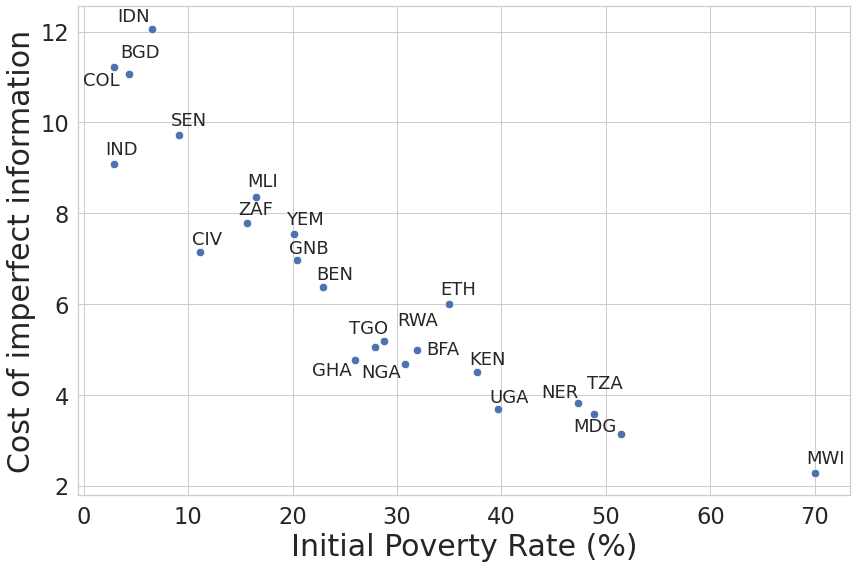

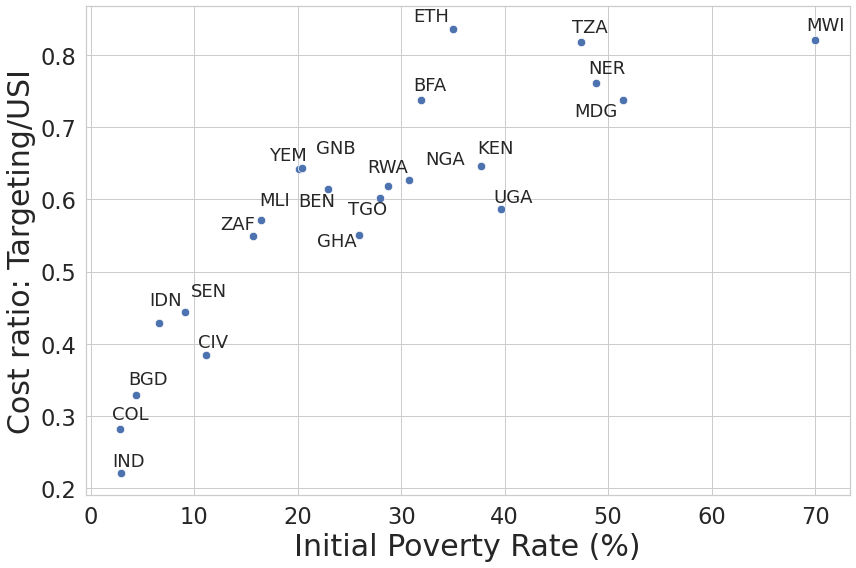

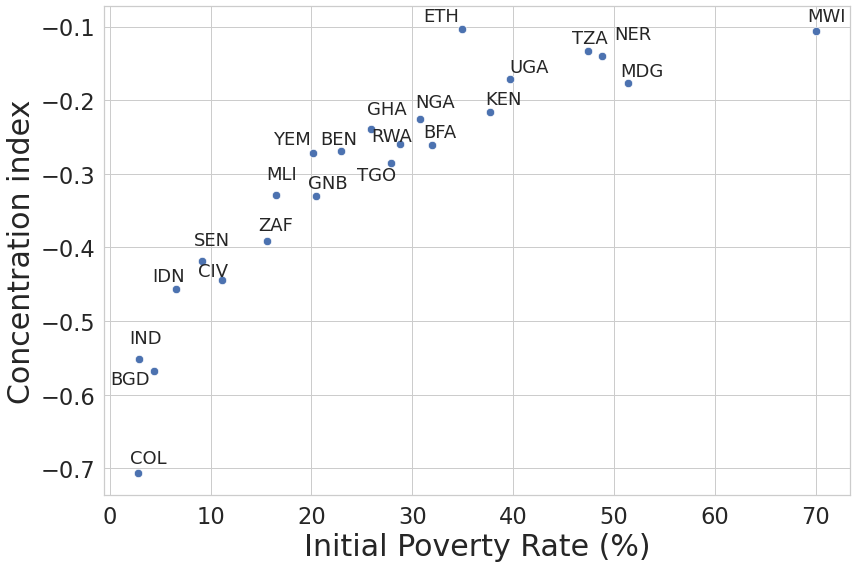

In [6]:
fontsize = 30

y_cols_and_labels = {
    'realistic_over_oracle': 'Cost of imperfect information',
    'targeting_over_ubi': 'Cost ratio: Targeting/USI',
    'concentration_index': 'Concentration index',
}
data['initial_poverty_rate_perc'] = data.initial_poverty_rate * 100

for y_col, y_label in y_cols_and_labels.items():
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(data=data, x='initial_poverty_rate_perc', y=y_col, ax=ax, s=70)
    texts = [ax.text(row['initial_poverty_rate_perc'], row[y_col], row['country'],
                     fontsize=18, ha='right', va='bottom')
             for _, row in data.iterrows()]
    adjust_text(texts, ax=ax)
    ax.set_xlabel('Initial Poverty Rate (%)', fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)
    ax.tick_params(axis="x", labelsize=fontsize * 0.75)
    ax.tick_params(axis="y", labelsize=fontsize * 0.75)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(paper_figures_out_path / f'{y_col}_vs_initial_poverty_rate_formatted.pdf', dpi=300, bbox_inches="tight")
    plt.show()

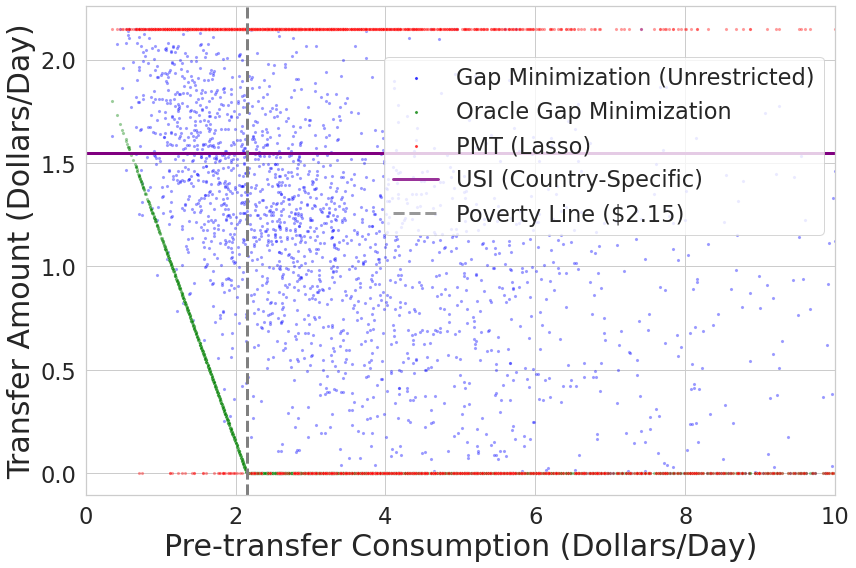

In [7]:
fontsize = 30

fig, ax = plt.subplots(figsize=(12, 8))

model_data = tgo_transfers[tgo_transfers["method"] == "output_gt_continuous_gap"]
sns.scatterplot(
    data=model_data,
    x="consumption", y="ev_transfer",
    color=METHODS["continuous_gap"]["color"],
    alpha=0.4, s=10,
    label=METHODS["continuous_gap"]["name"],
    ax=ax,
)

oracle_data = tgo_transfers[tgo_transfers["method"] == "oracle_gap"]
sns.scatterplot(
    data=oracle_data,
    x="consumption", y="ev_transfer",
    color=METHODS["oracle_gap"]["color"],
    alpha=0.4, s=10,
    label=METHODS["oracle_gap"]["name"],
    ax=ax,
)


pmt_data = tgo_transfers[tgo_transfers["method"] == "output_gt_pmt"]
sns.scatterplot(
    data=pmt_data,
    x="consumption", y="ev_transfer",
    color=METHODS["pmt"]["color"],
    alpha=0.4, s=10,
    label=METHODS["pmt"]["name"],
    ax=ax,
)

ubi_val = tgo_transfers[tgo_transfers["method"] == "ubi"]["ev_transfer"].iloc[0]
ax.axhline(ubi_val, color=METHODS["ubi"]["color"], linestyle=METHODS["ubi"]["linestyle"], label=METHODS["ubi"]["name"], linewidth=3)
ax.axvline(2.15, color="gray", linestyle="--", label="Poverty Line ($2.15)", linewidth=3)

ax.set_xlabel("Pre-transfer Consumption (Dollars/Day)", fontsize=fontsize)
ax.set_ylabel("Transfer Amount (Dollars/Day)", fontsize=fontsize)
ax.tick_params(axis="x", labelsize=fontsize * 0.75)
ax.tick_params(axis="y", labelsize=fontsize * 0.75)
legend = ax.legend(fontsize=fontsize * 0.75, loc='upper right', bbox_to_anchor=(1, 0.92))
for handle in legend.legend_handles:
    handle.set_alpha(0.8)
ax.set_xlim(0, 10)
ax.grid(True)
plt.tight_layout()
plt.savefig(paper_figures_out_path / "tgo_transfer_vs_consumption_formatted.pdf", dpi=300, bbox_inches="tight")
plt.show()

/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/selker/.conda/envs/leo_base/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


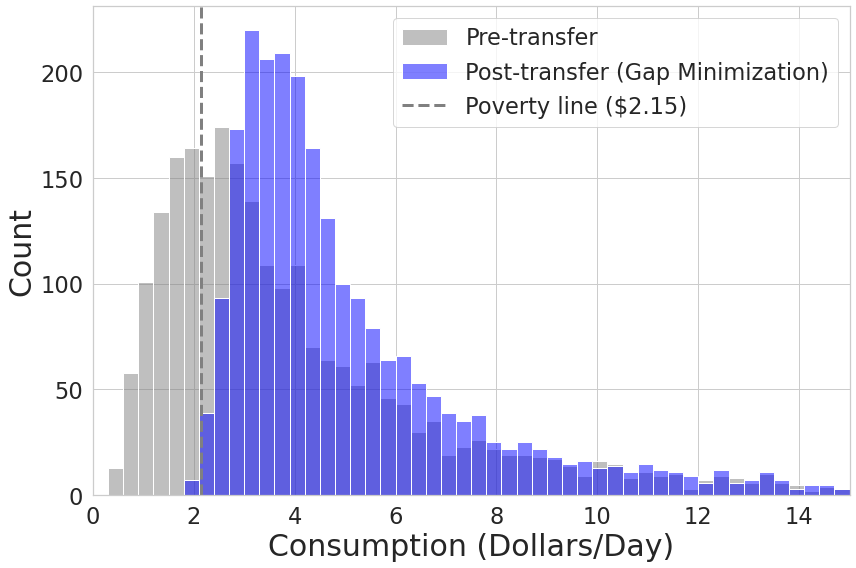

In [8]:
fontsize = 30
x_clip = 15

gap_data = tgo_transfers[tgo_transfers["method"] == "output_gt_continuous_gap"].copy()
gap_data["post_transfer_consumption"] = gap_data["consumption"] + gap_data["ev_transfer"]

color = METHODS["continuous_gap"]["color"]

fig, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=gap_data, x="consumption", bins=50, binrange=(0, x_clip),
             color='grey', alpha=0.5, label="Pre-transfer", ax=ax)
sns.histplot(data=gap_data, x="post_transfer_consumption", bins=50, binrange=(0, x_clip),
             color=color, alpha=0.5, label="Post-transfer (Gap Minimization)", ax=ax)
vline = ax.axvline(2.15, color="grey", linestyle="--", linewidth=3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [vline], labels=labels + ["Poverty line ($2.15)"],
          fontsize=fontsize * 0.75)

ax.set_xlabel("Consumption (Dollars/Day)", fontsize=fontsize)
ax.set_ylabel("Count", fontsize=fontsize)
ax.tick_params(axis="x", labelsize=fontsize * 0.75)
ax.tick_params(axis="y", labelsize=fontsize * 0.75)
ax.set_xlim(0, x_clip)
ax.grid(True)
plt.tight_layout()
plt.savefig(paper_figures_out_path / "tgo_consumption_pre_post_transfer_continuous_gap_formatted.pdf", dpi=300, bbox_inches="tight")
plt.show()

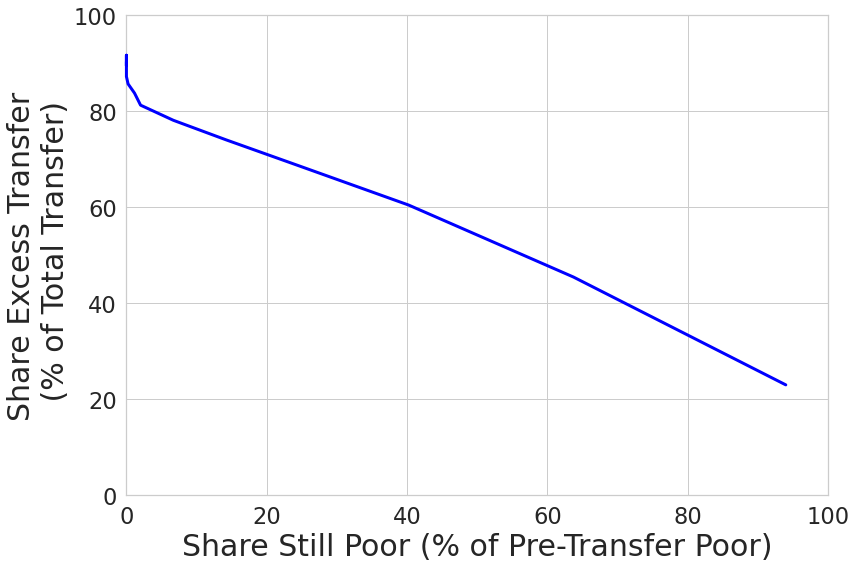

In [9]:
poverty_line = 2.15

overall_results = pd.read_csv(togo_country_results_path / "output_gt_continuous_gap.csv")

efficiencies = []
for _, row in overall_results.iterrows():
    budget = row["budget"]
    _, transfers = get_tranfers_file_for_budget(
        togo_country_results_path, "output_gt_continuous_gap", budget
    )

    joined = test_set.reset_index(drop=True).join(transfers.reset_index(drop=True))

    weights = joined["headcount_adjusted_hh_wgt"]
    gap = (poverty_line - joined["consumption"]).clip(lower=0)
    transfer = joined["ev_transfer"]

    gap_closing = np.minimum(transfer, gap)
    efficiency = (weights * gap_closing).sum() / (weights * transfer).sum()
    fraction_excess_transfers = (
        (weights * transfer).sum() - (weights * gap_closing).sum() 
    ) / (weights * transfer).sum()

    efficiencies.append({
        "post_transfer_poverty_rate": row["post_transfer_poverty_rate"],
        "pre_transfer_poverty_rate": row["initial_poverty_rate"],
        "efficiency": efficiency,
        "fraction_excess_transfers": fraction_excess_transfers
    })

efficiency_df = pd.DataFrame(efficiencies).sort_values("post_transfer_poverty_rate")
efficiency_df['efficiency_perc'] = efficiency_df.efficiency * 100
efficiency_df['fraction_excess_transfers_perc'] = efficiency_df.fraction_excess_transfers * 100

efficiency_df['post_transfer_poverty_rate_perc'] = (
    efficiency_df.post_transfer_poverty_rate / efficiency_df.pre_transfer_poverty_rate * 100
)
fontsize = 30

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(
    efficiency_df["post_transfer_poverty_rate_perc"],efficiency_df["fraction_excess_transfers_perc"], 
    color=METHODS["continuous_gap"]["color"],
    linestyle=METHODS["continuous_gap"]["linestyle"],
    linewidth=3,
    clip_on=False,
    zorder=5
)
ax.set_xlabel("Share Still Poor (% of Pre-Transfer Poor)", fontsize=fontsize)
ax.set_ylabel("Share Excess Transfer\n (% of Total Transfer)", fontsize=fontsize)

ax.tick_params(axis="x", labelsize=fontsize * 0.75)
ax.tick_params(axis="y", labelsize=fontsize * 0.75)
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.grid(True)
plt.tight_layout()
plt.savefig(paper_figures_out_path / "tgo_excess_transfer_vs_poor_reduction.pdf", dpi=300, bbox_inches="tight")
plt.show()

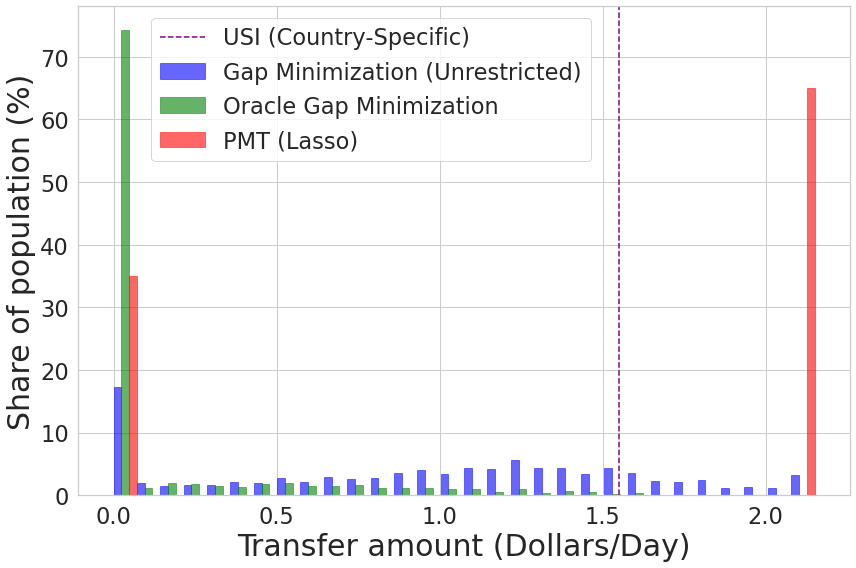

In [ ]:
fontsize = 30

fig, ax = plt.subplots(figsize=(12, 8))

method_colors = {
    "output_gt_continuous_gap": METHODS["continuous_gap"]["color"],
    "oracle_gap": METHODS["oracle_gap"]["color"],
    "output_gt_pmt": METHODS["pmt"]["color"],
    "ubi": METHODS["ubi_standard"]["color"],
}


hist_methods = ["output_gt_continuous_gap", "oracle_gap", "output_gt_pmt"]


# Shared bin edges
all_vals = tgo_transfers[tgo_transfers["method"].isin(hist_methods)]["ev_transfer"]
_, bin_edges = np.histogram(all_vals, bins=30)
bin_width = bin_edges[1] - bin_edges[0]
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

bar_width = bin_width / len(hist_methods)
offsets = np.linspace(-bin_width / 2 + bar_width / 2, bin_width / 2 - bar_width / 2, len(hist_methods))

for i, method in enumerate(hist_methods):
    if method.startswith('output_gt'):
        method_key = method[10:]
    else:
        method_key = method
    subset = tgo_transfers[tgo_transfers["method"] == method]
    vals = subset["ev_transfer"]
    weights = subset["headcount_adjusted_hh_wgt"]
    total_weight = weights.sum()
    pct, _ = np.histogram(vals, bins=bin_edges, weights=weights / total_weight * 100)
    ax.bar(centers + offsets[i], pct, width=bar_width, color=method_colors[method],
           alpha=0.6, edgecolor=method_colors[method], linewidth=0.8, label=METHODS[method_key]['name'])

# UBI vertical line
ubi_transfer = tgo_transfers[ tgo_transfers.method == 'ubi'].ev_transfer.values[0]
ax.axvline(ubi_transfer, label=METHODS['ubi']['name'], color=method_colors['ubi'],
            linestyle=METHODS["ubi_standard"]["linestyle"])

ax.legend(fontsize=fontsize * 0.75, loc='upper left', bbox_to_anchor=(0.08, 1))
ax.set_xlabel("Transfer Amount (Dollars/Day)", fontsize=fontsize)
ax.set_ylabel("Share of Population (%)", fontsize=fontsize)
ax.tick_params(axis="x", labelsize=fontsize * 0.75)
ax.tick_params(axis="y", labelsize=fontsize * 0.75)
# ax.set_yscale("log")

# ax.set_ylim(0, 350)
plt.tight_layout()
plt.savefig(paper_figures_out_path / "tgo_transfer_distribution_threeway_formatted.pdf", dpi=300)
plt.show()


# Scratch (Roshni ignore)

In [ ]:
sns.set_style("whitegrid")

y_cols_and_labels = {
    'spearman': 'Spearman: pre-transfer welfare vs inverse transfer size', 
    'realistic_over_oracle': 'Cost of imperfect information', 
    'ubi_over_targeting': 'Gain from targeting',
    'concentration_index': 'Concentration index',
}

for y_col, y_label in y_cols_and_labels.items():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x='initial_poverty_rate', y=y_col)
    texts = [plt.text(row['initial_poverty_rate'], row[y_col], row['country'], 
                      fontsize=8, ha='right', va='bottom') 
             for _, row in data.iterrows()]
    adjust_text(texts)
    plt.xlabel('Initial Poverty Rate')
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.savefig(f'../../figures/{y_col}_vs_initial_poverty_rate.png', dpi=300)
    plt.show()

In [ ]:
palette = sns.color_palette()
methods = ["output_gt_continuous_gap", "oracle_gap", "ubi"]
method_colors = {m: palette[i] for i, m in enumerate(methods)}

plt.figure(figsize=(10, 6))

# Scatter for the model
model_data = tgo_transfers[tgo_transfers["method"] == "output_gt_continuous_gap"]
sns.scatterplot(
    data=model_data,
    x="consumption", y="ev_transfer",
    color=method_colors["output_gt_continuous_gap"],
    alpha=0.4, s=10,
    label="output_gt_continuous_gap",
)

# Scatter for oracle
oracle_data = tgo_transfers[tgo_transfers["method"] == "oracle_gap"]
sns.scatterplot(
    data=oracle_data,
    x="consumption", y="ev_transfer",
    color=method_colors["oracle_gap"],
    alpha=0.4, s=10,
    label="oracle_gap",
)

# UBI: horizontal dotted line at the uniform transfer value
ubi_val = tgo_transfers[tgo_transfers["method"] == "ubi"]["ev_transfer"].iloc[0]
plt.axhline(ubi_val, color=method_colors["ubi"], linestyle="--", label="ubi")

plt.axvline(2.15, color='gray', linestyle="--", label="poverty line")

plt.xlabel("Pre-transfer consumption")
plt.ylabel("Transfer amount")
plt.legend(title="method")
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig("../../figures/tgo_transfer_vs_consumption.png", dpi=300)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette()
method_colors = {m: palette[i] for i, m in enumerate(
    ["output_gt_continuous_gap", "oracle_gap", "ubi", "output_gt_pmt"])
}

hist_methods = ["output_gt_continuous_gap", "oracle_gap", "output_gt_pmt"]

# Shared bin edges
all_vals = tgo_transfers[tgo_transfers["method"].isin(hist_methods)]["ev_transfer"]
_, bin_edges = np.histogram(all_vals, bins=30)
bin_width = bin_edges[1] - bin_edges[0]
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

bar_width = bin_width / len(hist_methods)
offsets = np.linspace(-bin_width / 2 + bar_width / 2, bin_width / 2 - bar_width / 2, len(hist_methods))

for i, method in enumerate(hist_methods):
    vals = tgo_transfers[tgo_transfers["method"] == method]["ev_transfer"]
    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(centers + offsets[i], counts, width=bar_width, color=method_colors[method],
           alpha=0.6, edgecolor=method_colors[method], linewidth=0.8, label=method)

# UBI vertical line
for method, grp in tgo_transfers.groupby("method"):
    if method in hist_methods:
        continue
    if grp["ev_transfer"].nunique() == 1:
        ax.axvline(grp["ev_transfer"].iloc[0], label=method, color=method_colors[method], linestyle="--")

ax.legend(title="method")
ax.set_xlabel("Transfer amount")
ax.set_ylabel("Count")
# ax.set_yscale("log")

# ax.set_ylim(0, 350)
plt.tight_layout()
plt.savefig("../../figures/tgo_transfer_distribution_threeway.png", dpi=300)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette()
method_colors = {m: palette[i] for i, m in enumerate(
    ["output_gt_continuous_gap", "oracle_gap", "ubi", "output_gt_pmt"])
}

offset_methods = ["output_gt_continuous_gap", "oracle_gap"]
background_method = "output_gt_pmt"

# Shared bin edges
all_vals = tgo_transfers[tgo_transfers["method"].isin(offset_methods)]["ev_transfer"]
_, bin_edges = np.histogram(all_vals, bins=30)
bin_width = bin_edges[1] - bin_edges[0]
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

if False:
    # Draw modern PMT full-width behind
    vals = tgo_transfers[tgo_transfers["method"] == background_method]["ev_transfer"]
    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(centers, counts, width=bin_width, color=method_colors[background_method],
        alpha=0.6, edgecolor=method_colors[background_method], linewidth=0.8, label=background_method)

# Draw offset_methods side-by-side on top
bar_width = bin_width / len(offset_methods)
offsets = np.linspace(-bin_width / 2 + bar_width / 2, bin_width / 2 - bar_width / 2, len(offset_methods))
for i, method in enumerate(offset_methods):
    vals = tgo_transfers[tgo_transfers["method"] == method]["ev_transfer"]
    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(centers + offsets[i], counts, width=bar_width, color=method_colors[method],
           alpha=0.6, edgecolor=method_colors[method], linewidth=0.8, label=method)

# UBI vertical line
for method, grp in tgo_transfers.groupby("method"):
    if method in offset_methods + [background_method]:
        continue
    if grp["ev_transfer"].nunique() == 1:
        ax.axvline(grp["ev_transfer"].iloc[0], label=method, color=method_colors[method], linestyle="--")

# Annotate the clipped first oracle bar with its actual count
oracle_vals = tgo_transfers[tgo_transfers["method"] == "oracle_gap"]["ev_transfer"]
counts, bin_edges = np.histogram(oracle_vals, bins=50)
first_bin_count = counts[0]
first_bin_center = (bin_edges[0] + bin_edges[1]) / 2
oracle_color = method_colors["oracle_gap"]
ylim_top = 350
ax.annotate(
    '',
    xy=(first_bin_center + bar_width , ylim_top),
    xytext=(first_bin_center + bar_width, ylim_top - 60),
    arrowprops=dict(arrowstyle='->', color=oracle_color),
)
ax.text(first_bin_center + bar_width, ylim_top + 10, str(first_bin_count),
        color=oracle_color, ha='center', va='bottom', fontsize=9, clip_on=False)

ax.legend(title="method")
ax.set_xlabel("Transfer amount")
ax.set_ylabel("Count")
ax.set_ylim(0, ylim_top)
plt.tight_layout()
plt.savefig("../../figures/tgo_transfer_distribution_offset_y_truncated.png", dpi=300)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette()
method_colors = {m: palette[i] for i, m in enumerate(["output_gt_continuous_gap", "oracle_gap", "ubi", "output_gt_pmt"])}

methods_ordered = [m for m in tgo_transfers["method"].unique() if m != "oracle_gap"] + ["oracle_gap"]

# Compute shared bin edges across all relevant methods
all_vals = tgo_transfers[
    (~tgo_transfers["method"].isin(["output_gt_pmt"])) &
    (tgo_transfers.groupby("method")["ev_transfer"].transform("nunique") > 1)
]["ev_transfer"]
bins = np.linspace(all_vals.min(), all_vals.max(), 31)  # 51 edges = 50 bins

for method in methods_ordered:
    grp = tgo_transfers[tgo_transfers["method"] == method]
    if method == 'output_gt_pmt':
        continue
    if grp["ev_transfer"].nunique() == 1:
        ax.axvline(grp["ev_transfer"].iloc[0], label=method, color=method_colors[method], linestyle="--")
    else:
        ax.hist(grp["ev_transfer"], bins=bins, label=method, color=method_colors[method], alpha=0.6)

# Annotate the clipped first oracle bar with its actual count
oracle_vals = tgo_transfers[tgo_transfers["method"] == "oracle_gap"]["ev_transfer"]
counts, bin_edges = np.histogram(oracle_vals, bins=50)
first_bin_count = counts[0]
first_bin_center = (bin_edges[0] + bin_edges[1]) / 2
oracle_color = method_colors["oracle_gap"]
ylim_top = 350
ax.annotate(
    '',
    xy=(first_bin_center , ylim_top),
    xytext=(first_bin_center , ylim_top - 60),
    arrowprops=dict(arrowstyle='->', color=oracle_color),
)
ax.text(first_bin_center , ylim_top + 10, str(first_bin_count),
        color=oracle_color, ha='center', va='bottom', fontsize=9, clip_on=False)

ax.legend(title="method")
ax.set_xlabel("Transfer amount")
ax.set_ylabel("Count")
ax.set_ylim(0, ylim_top)
plt.tight_layout()
plt.savefig("../../figures/tgo_transfer_distribution_overlap_y_truncated.png", dpi=300)
plt.show()

In [ ]:
gap_data = tgo_transfers[tgo_transfers["method"] == "output_gt_continuous_gap"].copy()
gap_data["post_transfer_consumption"] = gap_data["consumption"] + gap_data["ev_transfer"]

plot_df = pd.concat([
    gap_data[["consumption"]].rename(columns={"consumption": "value"}).assign(type="Pre-transfer"),
    gap_data[["post_transfer_consumption"]].rename(columns={"post_transfer_consumption": "value"}).assign(type="Post-transfer"),
])

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=plot_df, x="value", hue="type", bins=50, binrange=(0, 15), alpha=0.6, ax=ax)
vline = ax.axvline(2.15, color="gray", linestyle="--")

leg = ax.get_legend()
handles = leg.legend_handles + [vline]
labels = [t.get_text() for t in leg.get_texts()] + ["Poverty line ($2.15)"]
ax.legend(handles=handles, labels=labels)

ax.set_xlabel("Consumption")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../../figures/tgo_consumption_pre_post_transfer_continuous_gap.png", dpi=300)
plt.show()


In [ ]:
gap_data = tgo_transfers[tgo_transfers["method"] == "ubi"].copy()
gap_data["post_transfer_consumption"] = gap_data["consumption"] + gap_data["ev_transfer"]

plot_df = pd.concat([
    gap_data[["consumption"]].rename(columns={"consumption": "value"}).assign(type="Pre-transfer"),
    gap_data[["post_transfer_consumption"]].rename(columns={"post_transfer_consumption": "value"}).assign(type="Post-transfer"),
])

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=plot_df, x="value", hue="type", bins=50, binrange=(0, 15), alpha=0.6, ax=ax)
vline = ax.axvline(2.15, color="gray", linestyle="--")

leg = ax.get_legend()
handles = leg.legend_handles + [vline]
labels = [t.get_text() for t in leg.get_texts()] + ["Poverty line ($2.15)"]
ax.legend(handles=handles, labels=labels)

ax.set_xlabel("Consumption")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../../figures/tgo_consumption_pre_post_transfer_ubi.png", dpi=300)
plt.show()

## Geo

In [ ]:
import geopandas as gpd
cantons = gpd.read_file(
    '/data/togo_anon/geofiles/geofiles/TogoCantonGeoJsons/All_Togo_Cantons.geojson'
)
prefectures = gpd.read_file(
    '/data/togo_anon/geofiles/geofiles/TogoPrefectures/TogoAllPrefectures.geojson'
)

In [ ]:
level = "prefecture"  # "canton" or "prefecture"

level_config = {
    "canton":     {"shape": cantons,     "id_col": "Id",          "name_col": "Cantons"},
    "prefecture": {"shape": prefectures, "id_col": "PREFECTURE",  "name_col": "PREFECTURE"},
}
cfg = level_config[level]
shape = cfg["shape"]

# Spatial join once for all households (all methods share the same lat/lon)
all_data = tgo_transfers.dropna(subset=["latitude", "longitude"]).copy()
all_gdf = gpd.GeoDataFrame(
    all_data,
    geometry=gpd.points_from_xy(all_data["longitude"], all_data["latitude"]),
    crs="EPSG:4326",
)
joined = gpd.sjoin(all_gdf, shape[[cfg["id_col"], "geometry"]], how="left", predicate="within")

def weighted_mean_by_unit(method, value_col):
    sub = joined[joined["method"] == method]
    return (
        sub.groupby(cfg["id_col"])
        .apply(lambda g: np.average(g[value_col], weights=g["headcount_adjusted_hh_wgt"]))
        .reset_index(name=f"mean_{value_col}")
    )

transfer_stats_1 = weighted_mean_by_unit("output_gt_continuous_gap", "ev_transfer")
transfer_stats_2 = weighted_mean_by_unit("output_gt_pmt",     "ev_transfer")

panels = [
    ("Baseline consumption",       weighted_mean_by_unit("output_gt_continuous_gap", "consumption"),  "mean_consumption",  False),
    ("output_gt_continuous_gap",   transfer_stats_1,                                                  "mean_ev_transfer",  True),
    ("output_gt_pmt",              transfer_stats_2,                                                  "mean_ev_transfer",  True),
]

# Shared scale for the two transfer panels
transfer_vmin = min(transfer_stats_1["mean_ev_transfer"].min(), transfer_stats_2["mean_ev_transfer"].min())
transfer_vmax = max(transfer_stats_1["mean_ev_transfer"].max(), transfer_stats_2["mean_ev_transfer"].max())

# Nested GridSpec: left panel | right two panels (tight together)
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
fig = plt.figure(figsize=(18, 10))
gs_outer = GridSpec(1, 2, figure=fig, wspace=0.05)
gs_right = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0, 1], wspace=0.0)
axes = [
    fig.add_subplot(gs_outer[0, 0]),
    fig.add_subplot(gs_right[0, 0]),
    fig.add_subplot(gs_right[0, 1]),
]

for ax, (title, stats, val_col, is_transfer) in zip(axes, panels):
    togo_plot = shape.merge(stats, on=cfg["id_col"], how="left")
    plot_kwargs = dict(
        column=val_col,
        ax=ax,
        legend=False,
        cmap="YlOrRd",
        missing_kwds={"color": "lightgrey"},
    )
    if is_transfer:
        plot_kwargs["vmin"] = transfer_vmin
        plot_kwargs["vmax"] = transfer_vmax
    else:
        plot_kwargs["legend"] = True
        plot_kwargs["legend_kwds"] = {"label": "Weighted mean", "shrink": 0.6}
    togo_plot.plot(**plot_kwargs)
    ax.set_title(title)
    ax.set_axis_off()

# Single shared colorbar anchored to the right of the third panel only
import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap="YlOrRd", norm=mcolors.Normalize(vmin=transfer_vmin, vmax=transfer_vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes[2], location="right", shrink=0.6, pad=0.02, label="Weighted mean transfer")

plt.savefig(f"../../figures/tgo_heatmaps_by_{level}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
poverty_line = 2.15

overall_results = pd.read_csv(togo_country_results_path / "output_gt_continuous_gap.csv")

efficiencies = []
for _, row in overall_results.iterrows():
    budget = row["budget"]
    _, transfers = get_tranfers_file_for_budget(
        togo_country_results_path, "output_gt_continuous_gap", budget
    )
    joined = test_set.reset_index(drop=True).join(transfers.reset_index(drop=True))

    weights = joined["headcount_adjusted_hh_wgt"]
    gap = (poverty_line - joined["consumption"]).clip(lower=0)
    transfer = joined["ev_transfer"]

    gap_closing = np.minimum(transfer, gap)
    efficiency = (weights * gap_closing).sum() / (weights * transfer).sum()

    efficiencies.append({
        "post_transfer_poverty_rate": row["post_transfer_poverty_rate"],
        "efficiency": efficiency,
    })

efficiency_df = pd.DataFrame(efficiencies).sort_values("post_transfer_poverty_rate")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(efficiency_df["post_transfer_poverty_rate"], efficiency_df["efficiency"])
ax.set_xlabel("Post-transfer poverty rate")
ax.set_ylabel("Fraction of funds closing poverty gap")
plt.tight_layout()
plt.savefig("../../figures/tgo_targeting_efficiency_vs_poverty_rate.pdf", dpi=300)
plt.show()